In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
trade_files = [
    "data/raw/by_country/Argentina_trade_2014_2025.csv",
    "data/raw/by_country/Australia_trade_2014_2025.csv",
    "data/raw/by_country/Brazil_trade_2014_2025.csv",
    "data/raw/by_country/Canada_trade_2014_2025.csv",
    "data/raw/by_country/China_trade_2014_2025.csv",
    "data/raw/by_country/France_trade_2014_2025.csv",
    "data/raw/by_country/Germany_trade_2014_2025.csv",
    "data/raw/by_country/India_trade_2014_2025.csv",
    "data/raw/by_country/Indonesia_trade_2014_2025.csv",
    "data/raw/by_country/Italy_trade_2014_2025.csv",
    "data/raw/by_country/Japan_trade_2014_2025.csv",
    "data/raw/by_country/Mexico_trade_2014_2025.csv",
    "data/raw/by_country/Republic_of_Korea_trade_2014_2025.csv",
    "data/raw/by_country_second_key/Saudi_Arabia_trade_201401_202512.csv",
    "data/raw/by_country_second_key/South_Africa_trade_201401_202512.csv",
    "data/raw/by_country_second_key/Turkiye_trade_201401_202512.csv",
    "data/raw/by_country_second_key/United_Kingdom_trade_201401_202512.csv",
    "data/raw/by_country_second_key/United_States_trade_201401_202512.csv",
]

print("Number of selected trade files:", len(trade_files))

for file in trade_files:
    print(file)

Number of selected trade files: 18
data/raw/by_country/Argentina_trade_2014_2025.csv
data/raw/by_country/Australia_trade_2014_2025.csv
data/raw/by_country/Brazil_trade_2014_2025.csv
data/raw/by_country/Canada_trade_2014_2025.csv
data/raw/by_country/China_trade_2014_2025.csv
data/raw/by_country/France_trade_2014_2025.csv
data/raw/by_country/Germany_trade_2014_2025.csv
data/raw/by_country/India_trade_2014_2025.csv
data/raw/by_country/Indonesia_trade_2014_2025.csv
data/raw/by_country/Italy_trade_2014_2025.csv
data/raw/by_country/Japan_trade_2014_2025.csv
data/raw/by_country/Mexico_trade_2014_2025.csv
data/raw/by_country/Republic_of_Korea_trade_2014_2025.csv
data/raw/by_country_second_key/Saudi_Arabia_trade_201401_202512.csv
data/raw/by_country_second_key/South_Africa_trade_201401_202512.csv
data/raw/by_country_second_key/Turkiye_trade_201401_202512.csv
data/raw/by_country_second_key/United_Kingdom_trade_201401_202512.csv
data/raw/by_country_second_key/United_States_trade_201401_202512.csv

In [3]:
all_data = []

for file in trade_files:
    temp = pd.read_csv(file)
    all_data.append(temp)

trade_df = pd.concat(all_data, ignore_index=True)

print("Combined trade data shape:", trade_df.shape)
print("Number of countries:", trade_df["country_name"].nunique())
print("Countries:")
print(sorted(trade_df["country_name"].unique()))

Combined trade data shape: (5066, 48)
Number of countries: 18
Countries:
['Argentina', 'Australia', 'Brazil', 'Canada', 'China', 'France', 'Germany', 'India', 'Indonesia', 'Italy', 'Japan', 'Mexico', 'Republic_of_Korea', 'Saudi_Arabia', 'South_Africa', 'Turkiye', 'United_Kingdom', 'United_States']


In [4]:
trade_df = trade_df[(trade_df["period"] >= 201401) & (trade_df["period"] <= 202412)]

print("Shape after keeping 2014 to 2024:", trade_df.shape)
print("Minimum period:", trade_df["period"].min())
print("Maximum period:", trade_df["period"].max())
print("Number of countries:", trade_df["country_name"].nunique())

Shape after keeping 2014 to 2024: (4668, 48)
Minimum period: 201401
Maximum period: 202412
Number of countries: 18


In [5]:
trade_df["date"] = pd.to_datetime(
    trade_df["period"].astype(str),
    format="%Y%m"
)

trade_df["year"] = trade_df["date"].dt.year
trade_df["month"] = trade_df["date"].dt.month
trade_df["quarter"] = trade_df["date"].dt.quarter

print(trade_df[["period", "date", "year", "month", "quarter"]].head())

   period       date  year  month  quarter
0  201401 2014-01-01  2014      1        1
1  201401 2014-01-01  2014      1        1
2  201402 2014-02-01  2014      2        1
3  201402 2014-02-01  2014      2        1
4  201403 2014-03-01  2014      3        1


In [6]:
trade_df = trade_df[
    [
        "country_name",
        "period",
        "date",
        "year",
        "month",
        "quarter",
        "flowCode",
        "flowDesc",
        "primaryValue"
    ]
]
print("Clean Trade data shape:",trade_df.shape)
print(trade_df.head())

Clean Trade data shape: (4668, 9)
  country_name  period       date  year  month  quarter flowCode flowDesc  \
0    Argentina  201401 2014-01-01  2014      1        1        M   Import   
1    Argentina  201401 2014-01-01  2014      1        1        X   Export   
2    Argentina  201402 2014-02-01  2014      2        1        M   Import   
3    Argentina  201402 2014-02-01  2014      2        1        X   Export   
4    Argentina  201403 2014-03-01  2014      3        1        M   Import   

   primaryValue  
0  5.218059e+09  
1  4.275126e+09  
2  5.539307e+09  
3  4.647254e+09  
4  5.524368e+09  


In [10]:
external_df = pd.read_csv("external_features_with_fedfunds.csv")

print("External features shape:", external_df.shape)
print(external_df.head())
print("columns:")
print(external_df.columns.tolist())

External features shape: (132, 15)
       period  crude_oil_avg_usd  brent_price_usd  dubai_price_usd  \
0  2014-01-01           102.0967           107.42           104.01   
1  2014-02-01           104.8267           108.81           104.94   
2  2014-03-01           104.0400           107.40           104.15   
3  2014-04-01           104.8667           107.79           104.73   
4  2014-05-01           105.7133           109.68           105.60   

   wti_price_usd  commodity_total_index  energy_index  non_energy_index  \
0          94.86               119.9302      131.2182           97.0601   
1         100.73               122.0227      133.9666           97.9067   
2         100.57               120.4567      130.6676           99.9456   
3         102.08               120.4596      130.6783           99.9672   
4         101.86               121.4330      132.3273           99.5266   

   agriculture_index  food_index  fertilizers_index  metals_minerals_index  \
0           100

In [11]:
external_df["date"] = pd.to_datetime(external_df["period"])
external_df = external_df.drop(columns=["period"])
print("External features after date cleanup:")
print(external_df.head())
print("Shape:", external_df.shape)

External features after date cleanup:
   crude_oil_avg_usd  brent_price_usd  dubai_price_usd  wti_price_usd  \
0           102.0967           107.42           104.01          94.86   
1           104.8267           108.81           104.94         100.73   
2           104.0400           107.40           104.15         100.57   
3           104.8667           107.79           104.73         102.08   
4           105.7133           109.68           105.60         101.86   

   commodity_total_index  energy_index  non_energy_index  agriculture_index  \
0               119.9302      131.2182           97.0601           100.9646   
1               122.0227      133.9666           97.9067           103.2064   
2               120.4567      130.6676           99.9456           108.0716   
3               120.4596      130.6783           99.9672           107.3121   
4               121.4330      132.3273           99.5266           106.8779   

   food_index  fertilizers_index  metals_mineral

In [12]:
model_df = pd.merge(
    trade_df,
    external_df,
    on="date",
    how="left"
)
print("Merged model data shape:", model_df.shape)
print(model_df.head())

Merged model data shape: (4668, 23)
  country_name  period       date  year  month  quarter flowCode flowDesc  \
0    Argentina  201401 2014-01-01  2014      1        1        M   Import   
1    Argentina  201401 2014-01-01  2014      1        1        X   Export   
2    Argentina  201402 2014-02-01  2014      2        1        M   Import   
3    Argentina  201402 2014-02-01  2014      2        1        X   Export   
4    Argentina  201403 2014-03-01  2014      3        1        M   Import   

   primaryValue  crude_oil_avg_usd  ...  commodity_total_index  energy_index  \
0  5.218059e+09           102.0967  ...               119.9302      131.2182   
1  4.275126e+09           102.0967  ...               119.9302      131.2182   
2  5.539307e+09           104.8267  ...               122.0227      133.9666   
3  4.647254e+09           104.8267  ...               122.0227      133.9666   
4  5.524368e+09           104.0400  ...               120.4567      130.6676   

   non_energy_index 

In [13]:
macro_df = pd.read_csv("new_external_macro_features_2014_2024.csv")
print("Macro external feat shape:", macro_df.shape)
print(macro_df.head())
print("Columns:")
print(macro_df.columns.tolist())

Macro external feat shape: (132, 8)
         date  usd_broad_index  us_industrial_production   us_cpi  \
0  2014-01-01        94.464748                  100.1599  235.288   
1  2014-02-01        94.645582                  100.9168  235.547   
2  2014-03-01        94.440821                  101.8942  236.028   
3  2014-04-01        93.995550                  101.9928  236.468   
4  2014-05-01        93.670029                  102.3836  236.918   

   fed_funds_rate  us_10y_treasury_rate  global_policy_uncertainty  \
0            0.07              2.858095                 115.257559   
1            0.07              2.709474                 101.147273   
2            0.08              2.723333                 114.652379   
3            0.09              2.705238                 110.450150   
4            0.09              2.559048                 106.839074   

   deep_sea_freight_ppi  
0                 263.0  
1                 262.2  
2                 262.1  
3                 263.3 

In [16]:
macro_df["date"] = pd.to_datetime(macro_df["date"])
macro_df = macro_df.drop(columns=["fed_funds_rate"])
model_df = pd.merge(
    model_df,
    macro_df,
    on="date",
    how="left"
)

print("Model data shape w macro feat:", model_df.shape)
print(model_df.head())

Model data shape w macro feat: (4668, 29)
  country_name  period       date  year  month  quarter flowCode flowDesc  \
0    Argentina  201401 2014-01-01  2014      1        1        M   Import   
1    Argentina  201401 2014-01-01  2014      1        1        X   Export   
2    Argentina  201402 2014-02-01  2014      2        1        M   Import   
3    Argentina  201402 2014-02-01  2014      2        1        X   Export   
4    Argentina  201403 2014-03-01  2014      3        1        M   Import   

   primaryValue  crude_oil_avg_usd  ...  metals_minerals_index  \
0  5.218059e+09           102.0967  ...                88.0757   
1  4.275126e+09           102.0967  ...                88.0757   
2  5.539307e+09           104.8267  ...                86.1633   
3  4.647254e+09           104.8267  ...                86.1633   
4  5.524368e+09           104.0400  ...                82.9794   

   base_metals_index  precious_metals_index  fed_funds_rate  usd_broad_index  \
0            88.13

In [17]:
missing = model_df.isna().sum()
missing=missing[missing>0]
print("Missing values:")
print(missing)

Missing values:
Series([], dtype: int64)


In [22]:
cols_to_drop = [
    "brent_price_usd",
    "dubai_price_usd",
    "wti_price_usd",
    "commodity_total_index",
    "agriculture_index",
    "metals_minerals_index"
]

model_df = model_df.drop(columns=cols_to_drop, errors="ignore")

In [23]:
model_df.to_csv("clean_final_data.csv", index=False)
print("Saved file: clean_final_data.csv")
print("Final shape:", model_df.shape)

Saved file: clean_final_data.csv
Final shape: (4668, 23)


In [26]:
external_cols = [
    "crude_oil_avg_usd",
    "energy_index",
    "non_energy_index",
    "food_index",
    "fertilizers_index",
    "base_metals_index",
    "precious_metals_index",
    "fed_funds_rate",
    "usd_broad_index",
    "us_industrial_production",
    "us_cpi",
    "us_10y_treasury_rate",
    "global_policy_uncertainty",
    "deep_sea_freight_ppi"
]

model_df = model_df.sort_values("date")

for col in external_cols:
    model_df[col + "_lag1"] = model_df[col].shift(1)

print("Share after lag 1:", model_df.shape)

Share after lag 1: (4668, 37)


In [27]:
#removing rows without lags
model_df = model_df.dropna()
print("shapa after missing lag:", model_df.shape)

shapa after missing lag: (4667, 37)


In [31]:
model_df["log_primaryValue"] = np.log1p(model_df["primaryValue"])
print(model_df[["primaryValue", "log_primaryValue"]].head())

      primaryValue  log_primaryValue
4404  1.896900e+11         25.968657
1     4.275126e+09         22.176079
4405  1.274311e+11         25.570841
4141  4.417509e+10         24.511427
264   1.992291e+10         23.715136


In [32]:
model_df = model_df.sort_values(["country_name", "flowCode", "date"])
print(model_df[["country_name", "flowCode", "date", "primaryValue", "log_primaryValue"]].head())

   country_name flowCode       date  primaryValue  log_primaryValue
2     Argentina        M 2014-02-01  5.539307e+09         22.435135
4     Argentina        M 2014-03-01  5.524368e+09         22.432435
6     Argentina        M 2014-04-01  5.414486e+09         22.412344
8     Argentina        M 2014-05-01  5.760059e+09         22.474213
10    Argentina        M 2014-06-01  5.979561e+09         22.511613


In [33]:
#dummy variables for country name and flowcode
model_df_encoded = pd.get_dummies(
    model_df,
    columns=["country_name","flowCode"],
)
print("Shape after encoding:", model_df_encoded.shape)

Shape after encoding: (4667, 56)


In [34]:
train_df = model_df_encoded[model_df_encoded["year"] <=2023]
test_df = model_df_encoded[model_df_encoded["year"]==2024]
print("train shape:",train_df.shape)
print("test shape:", test_df.shape)

train shape: (4235, 56)
test shape: (432, 56)


In [35]:
drop_cols = [
    "primaryValue",
    "log_primaryValue",
    "date",
    "period",
    "flowDesc"
]

X_train = train_df.drop(columns=drop_cols)
y_train = train_df["log_primaryValue"]

X_test = test_df.drop(columns=drop_cols)
y_test = test_df["log_primaryValue"]

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (4235, 51)
y_train shape: (4235,)
X_test shape: (432, 51)
y_test shape: (432,)


In [36]:
from sklearn.linear_model import LinearRegression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
print("Linear Regression Model trained")

Linear Regression Model trained


In [38]:
y_pred_log = lr_model.predict(X_test)
print("predictions created")
print(y_pred_log[:5])

predictions created
[22.54092181 22.55918163 22.57852069 22.56118814 22.58739038]


In [42]:
y_pred = np.expm1(y_pred_log)
y_test_actual = np.expm1(y_test)
print("First 5 values:")
print(y_test_actual.head())
print("First 5 predicted vaues:")
print(y_pred[:5])

First 5 values:
240    4.603955e+09
242    4.118057e+09
244    4.331571e+09
246    4.704521e+09
248    5.012117e+09
Name: log_primaryValue, dtype: float64
First 5 predicted vaues:
[6.15740841e+09 6.27087432e+09 6.39332739e+09 6.28346957e+09
 6.45028643e+09]


In [43]:
mae = mean_absolute_error(y_test_actual, y_pred)
rmse = np.sqrt(mean_squared_error(y_test_actual,y_pred))
r2 = r2_score(y_test_actual, y_pred)

mape = np.mean(abs((y_test_actual - y_pred) / y_test_actual)) * 100

print("Linear Regression results")
print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)
print("MAPE:", mape)

Linear Regression results
MAE: 10312257153.029554
RMSE: 19591707149.710888
R2: 0.9221397781401882
MAPE: 13.694407519467525


In [47]:
lr_results = pd.DataFrame({
    "Model": ["Linear Regression"],
    "MAE (USD bn)": [mae/1_000_000_000],
    "RMSE (USD bn)": [rmse/1_000_000_000],
    "R2": [r2],
    "MAPE (%)": [mape]
        })
lr_results.round(2)

,Model,MAE (USD bn),RMSE (USD bn),R2,MAPE (%)
0,Linear Regression,10.31,19.59,0.92,13.69


In [48]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Random Forest model trained")

Random Forest model trained


In [50]:
rf_pred_log = rf_model.predict(X_test)
rf_pred = np.expm1(rf_pred_log)

print("Random Forest prediction created")
print(rf_pred[:5])

Random Forest prediction created
[5.09404419e+09 5.16230797e+09 5.40461034e+09 5.29789942e+09
 5.38408402e+09]


In [55]:
rf_mae = mean_absolute_error(y_test_actual, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test_actual, rf_pred))
rf_r2 = r2_score(y_test_actual, rf_pred)

rf_mape = np.mean(abs((y_test_actual - rf_pred) / y_test_actual)) * 100

print("Random Forest results")
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R2:", rf_r2)
print("MAPE:", rf_mape)

Random Forest results
MAE: 4228940645.7116475
RMSE: 7774607228.689744
R2: 0.987738940737967
MAPE: 7.01492812259715


In [56]:
rf_results = pd.DataFrame({
    "Model": ["Random Forest"],
    "MAE (USD bn)": [rf_mae/1_000_000_000],
    "RMSE (USD bn)": [rf_rmse/1_000_000_000],
    "R2": [rf_r2],
    "MAPE (%)": [rf_mape]
        })
rf_results.round(2)

,Model,MAE (USD bn),RMSE (USD bn),R2,MAPE (%)
0,Random Forest,4.23,7.77,0.99,7.01


In [57]:
mvp_results = pd.concat([lr_results, rf_results], ignore_index=True)

mvp_results.round(2)

,Model,MAE (USD bn),RMSE (USD bn),R2,MAPE (%)
0,Linear Regression,10.31,19.59,0.92,13.69
1,Random Forest,4.23,7.77,0.99,7.01


In [59]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled data created")

Scaled data created


In [60]:
from sklearn.svm import SVR

svr_model = SVR(
    kernel="rbf",
    C=10,
    epsilon=0.1
)
svr_model.fit(X_train_scaled, y_train)
print("SVR model trained")

SVR model trained


In [61]:
svr_pred_log = svr_model.predict(X_test_scaled)
svr_pred = np.expm1(svr_pred_log)
print("SVR predictions created")
print(svr_pred[:5])

SVR predictions created
[8.36472066e+09 9.04565171e+09 8.96129273e+09 8.98879212e+09
 8.55953343e+09]


In [63]:
svr_mae = mean_absolute_error(y_test_actual, svr_pred)
svr_rmse = np.sqrt(mean_squared_error(y_test_actual, svr_pred))
svr_r2 = r2_score(y_test_actual, svr_pred)

svr_mape = np.mean(abs((y_test_actual - svr_pred) / y_test_actual)) * 100

print("SVR results")
print("MAE:", svr_mae)
print("RMSE:", svr_rmse)
print("R2:", svr_r2)
print("MAPE:", svr_mape)

SVR results
MAE: 16831527033.135117
RMSE: 35882374135.366905
R2: 0.7388239097823939
MAPE: 19.03809786747514


In [64]:
svr_results = pd.DataFrame({
    "Model": ["SVR"],
    "MAE (USD bn)": [svr_mae/1_000_000_000],
    "RMSE (USD bn)": [svr_rmse/1_000_000_000],
    "R2": [svr_r2],
    "MAPE (%)": [svr_mape]
        })
svr_results.round(2)

,Model,MAE (USD bn),RMSE (USD bn),R2,MAPE (%)
0,SVR,16.83,35.88,0.74,19.04


In [65]:
model_df = pd.read_csv("clean_final_data.csv")

model_df["date"] = pd.to_datetime(model_df["date"])

print(model_df.shape)
print(model_df.head())

(4668, 23)
  country_name  period       date  year  month  quarter flowCode flowDesc  \
0    Argentina  201401 2014-01-01  2014      1        1        M   Import   
1    Argentina  201401 2014-01-01  2014      1        1        X   Export   
2    Argentina  201402 2014-02-01  2014      2        1        M   Import   
3    Argentina  201402 2014-02-01  2014      2        1        X   Export   
4    Argentina  201403 2014-03-01  2014      3        1        M   Import   

   primaryValue  crude_oil_avg_usd  ...  fertilizers_index  base_metals_index  \
0  5.218059e+09           102.0967  ...           105.6653            88.1316   
1  4.275126e+09           102.0967  ...           105.6653            88.1316   
2  5.539307e+09           104.8267  ...           105.6094            86.8503   
3  4.647254e+09           104.8267  ...           105.6094            86.8503   
4  5.524368e+09           104.0400  ...           102.5986            84.4461   

   precious_metals_index  fed_funds_rat

In [67]:
external_cols = [
    "crude_oil_avg_usd",
    "energy_index",
    "non_energy_index",
    "food_index",
    "fertilizers_index",
    "base_metals_index",
    "precious_metals_index",
    "fed_funds_rate",
    "usd_broad_index",
    "us_industrial_production",
    "us_cpi",
    "us_10y_treasury_rate",
    "global_policy_uncertainty",
    "deep_sea_freight_ppi"
]

monthly_external = model_df[["date"] + external_cols].drop_duplicates()

monthly_external = monthly_external.sort_values("date")

for col in external_cols:
    monthly_external[col + "_lag1"] = monthly_external[col].shift(1)

print(monthly_external.head())

        date  crude_oil_avg_usd  energy_index  non_energy_index  food_index  \
0 2014-01-01           102.0967      131.2182           97.0601    106.5227   
2 2014-02-01           104.8267      133.9666           97.9067    108.2873   
4 2014-03-01           104.0400      130.6676           99.9456    113.8253   
6 2014-04-01           104.8667      130.6783           99.9672    112.3142   
8 2014-05-01           105.7133      132.3273           99.5266    112.0518   

   fertilizers_index  base_metals_index  precious_metals_index  \
0           105.6653            88.1316               100.5996   
2           105.6094            86.8503               105.0007   
4           102.5986            84.4461               107.2837   
6            94.9084            87.0879               103.9296   
8            96.0311            88.5446               102.9955   

   fed_funds_rate  usd_broad_index  ...  fertilizers_index_lag1  \
0            0.07        94.464748  ...                     N

In [69]:
lag_cols = ["date"] + [col + "_lag1" for col in external_cols]
model_df = pd.merge(
    model_df,
    monthly_external[lag_cols],
    on="date",
    how="left"
)
print("Shape after adding correct lag features:", model_df.shape)

Shape after adding correct lag features: (4668, 37)


In [70]:
model_df = model_df.dropna()

print("Shape after removing missing lag rows:", model_df.shape)
print("First date:", model_df["date"].min())

Shape after removing missing lag rows: (4636, 37)
First date: 2014-02-01 00:00:00


In [71]:
model_df = model_df.drop(columns=external_cols)

print("Shape after removing current-month external values:", model_df.shape)
print(model_df.columns.tolist())

Shape after removing current-month external values: (4636, 23)
['country_name', 'period', 'date', 'year', 'month', 'quarter', 'flowCode', 'flowDesc', 'primaryValue', 'crude_oil_avg_usd_lag1', 'energy_index_lag1', 'non_energy_index_lag1', 'food_index_lag1', 'fertilizers_index_lag1', 'base_metals_index_lag1', 'precious_metals_index_lag1', 'fed_funds_rate_lag1', 'usd_broad_index_lag1', 'us_industrial_production_lag1', 'us_cpi_lag1', 'us_10y_treasury_rate_lag1', 'global_policy_uncertainty_lag1', 'deep_sea_freight_ppi_lag1']


In [72]:
model_df["log_primaryValue"] = np.log1p(model_df["primaryValue"])

print(model_df[["primaryValue", "log_primaryValue"]].head())

   primaryValue  log_primaryValue
2  5.539307e+09         22.435135
3  4.647254e+09         22.259542
4  5.524368e+09         22.432435
5  4.913932e+09         22.315340
6  5.414486e+09         22.412344


In [74]:
#dummy variables for country name and flowcode
model_df_encoded = pd.get_dummies(
    model_df,
    columns=["country_name","flowCode"],
    drop_first=True
)
print("Shape after encoding:", model_df_encoded.shape)

Shape after encoding: (4636, 40)


In [75]:
train_df = model_df_encoded[model_df_encoded["year"] <=2023]
test_df = model_df_encoded[model_df_encoded["year"]==2024]
print("train shape:",train_df.shape)
print("test shape:", test_df.shape)

train shape: (4204, 40)
test shape: (432, 40)


In [76]:
drop_cols = [
    "primaryValue",
    "log_primaryValue",
    "date",
    "period",
    "flowDesc"
]

X_train = train_df.drop(columns=drop_cols)
y_train = train_df["log_primaryValue"]

X_test = test_df.drop(columns=drop_cols)
y_test = test_df["log_primaryValue"]

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (4204, 35)
y_train shape: (4204,)
X_test shape: (432, 35)
y_test shape: (432,)


In [77]:
from sklearn.linear_model import LinearRegression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
print("Linear Regression Model trained")

Linear Regression Model trained


In [78]:
y_pred = np.expm1(y_pred_log)
y_test_actual = np.expm1(y_test)
print("First 5 values:")
print(y_test_actual.head())
print("First 5 predicted vaues:")
print(y_pred[:5])

First 5 values:
240    4.603955e+09
241    5.412324e+09
242    4.118057e+09
243    5.550152e+09
244    4.331571e+09
Name: log_primaryValue, dtype: float64
First 5 predicted vaues:
[6.15740841e+09 6.27087432e+09 6.39332739e+09 6.28346957e+09
 6.45028643e+09]


In [79]:
mae = mean_absolute_error(y_test_actual, y_pred)
rmse = np.sqrt(mean_squared_error(y_test_actual,y_pred))
r2 = r2_score(y_test_actual, y_pred)

mape = np.mean(abs((y_test_actual - y_pred) / y_test_actual)) * 100

print("Linear Regression results")
print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)
print("MAPE:", mape)

Linear Regression results
MAE: 10246918622.368803
RMSE: 19560368172.85489
R2: 0.9223886699909476
MAPE: 13.734235800206877


In [80]:
lr_results = pd.DataFrame({
    "Model": ["Linear Regression"],
    "MAE (USD bn)": [mae/1_000_000_000],
    "RMSE (USD bn)": [rmse/1_000_000_000],
    "R2": [r2],
    "MAPE (%)": [mape]
        })
lr_results.round(3)

,Model,MAE (USD bn),RMSE (USD bn),R2,MAPE (%)
0,Linear Regression,10.247,19.56,0.922,13.734


In [81]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Random Forest model trained")

Random Forest model trained


In [82]:
rf_pred_log = rf_model.predict(X_test)
rf_pred = np.expm1(rf_pred_log)

print("Random Forest prediction created")
print(rf_pred[:5])

Random Forest prediction created
[5.48274181e+09 5.40187579e+09 5.37786871e+09 5.36546626e+09
 5.37109139e+09]


In [83]:
rf_mae = mean_absolute_error(y_test_actual, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test_actual, rf_pred))
rf_r2 = r2_score(y_test_actual, rf_pred)

rf_mape = np.mean(abs((y_test_actual - rf_pred) / y_test_actual)) * 100

print("Random Forest results")
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R2:", rf_r2)
print("MAPE:", rf_mape)

Random Forest results
MAE: 5020901563.862077
RMSE: 8941761374.442175
R2: 0.9837812556741437
MAPE: 8.277434387115946


In [91]:
rf_results = pd.DataFrame({
    "Model": ["Random Forest"],
    "MAE (USD bn)": [rf_mae/1_000_000_000],
    "RMSE (USD bn)": [rf_rmse/1_000_000_000],
    "R2": [rf_r2],
    "MAPE (%)": [rf_mape]
        })
rf_results.round(3)

,Model,MAE (USD bn),RMSE (USD bn),R2,MAPE (%)
0,Random Forest,5.021,8.942,0.984,8.277


In [85]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled data created")

Scaled data created


In [86]:
from sklearn.svm import SVR

svr_model = SVR(
    kernel="rbf",
    C=10,
    epsilon=0.1
)
svr_model.fit(X_train_scaled, y_train)
print("SVR model trained")

SVR model trained


In [87]:
svr_pred_log = svr_model.predict(X_test_scaled)
svr_pred = np.expm1(svr_pred_log)
print("SVR predictions created")
print(svr_pred[:5])

SVR predictions created
[9.57380292e+09 8.49620567e+09 9.72124576e+09 8.69016039e+09
 9.37607152e+09]


In [88]:
svr_mae = mean_absolute_error(y_test_actual, svr_pred)
svr_rmse = np.sqrt(mean_squared_error(y_test_actual, svr_pred))
svr_r2 = r2_score(y_test_actual, svr_pred)

svr_mape = np.mean(abs((y_test_actual - svr_pred) / y_test_actual)) * 100

print("SVR results")
print("MAE:", svr_mae)
print("RMSE:", svr_rmse)
print("R2:", svr_r2)
print("MAPE:", svr_mape)

SVR results
MAE: 13317476389.23297
RMSE: 18044748762.966415
R2: 0.9339500101140443
MAPE: 33.71700777566854


In [90]:
svr_results = pd.DataFrame({
    "Model": ["SVR"],
    "MAE (USD bn)": [svr_mae/1_000_000_000],
    "RMSE (USD bn)": [svr_rmse/1_000_000_000],
    "R2": [svr_r2],
    "MAPE (%)": [svr_mape]
        })
svr_results.round(3)

,Model,MAE (USD bn),RMSE (USD bn),R2,MAPE (%)
0,SVR,13.317,18.045,0.934,33.717


In [92]:
mvp_results = pd.concat([lr_results, rf_results, svr_results], ignore_index=True)

mvp_results.round(3)

,Model,MAE (USD bn),RMSE (USD bn),R2,MAPE (%)
0,Linear Regression,10.247,19.560,0.922,13.734
1,Random Forest,5.021,8.942,0.984,8.277
2,SVR,13.317,18.045,0.934,33.717


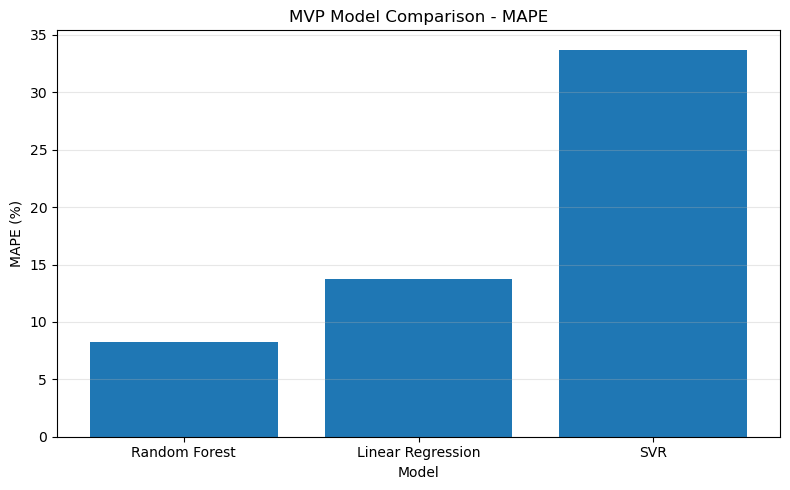

In [93]:
plot_df = mvp_results.sort_values("MAPE (%)")

plt.figure(figsize=(8, 5))
plt.bar(plot_df["Model"], plot_df["MAPE (%)"])

plt.title("MVP Model Comparison - MAPE")
plt.xlabel("Model")
plt.ylabel("MAPE (%)")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

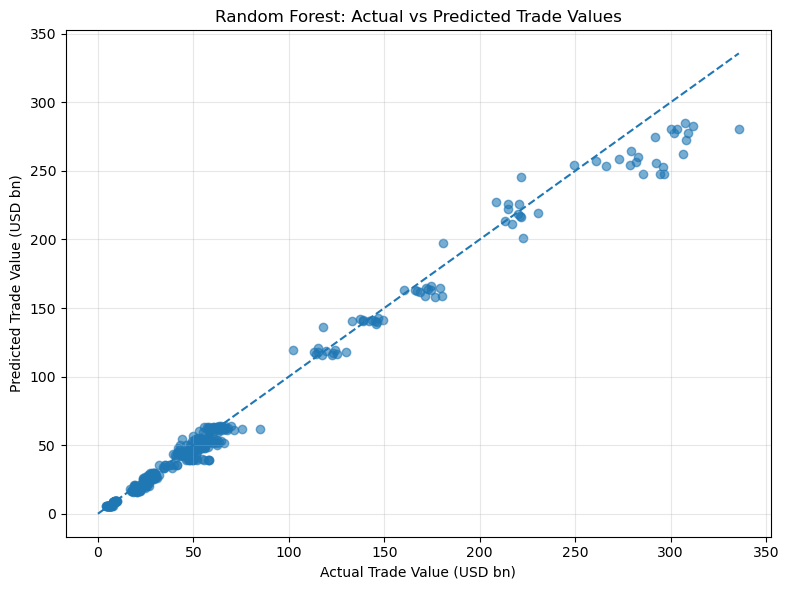

In [94]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test_actual / 1_000_000_000,
    rf_pred / 1_000_000_000,
    alpha=0.6
)

max_value = max(
    y_test_actual.max() / 1_000_000_000,
    rf_pred.max() / 1_000_000_000
)

plt.plot(
    [0, max_value],
    [0, max_value],
    linestyle="--"
)

plt.title("Random Forest: Actual vs Predicted Trade Values")
plt.xlabel("Actual Trade Value (USD bn)")
plt.ylabel("Predicted Trade Value (USD bn)")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

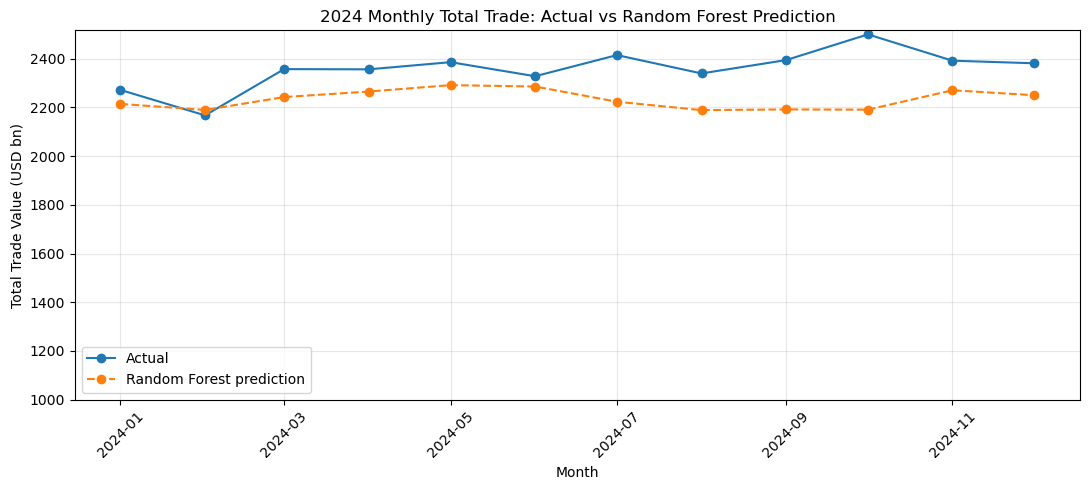

In [98]:
rf_plot_df = test_df[["date"]].copy()

rf_plot_df["Actual Trade Value"] = y_test_actual.values / 1_000_000_000
rf_plot_df["Predicted Trade Value"] = rf_pred / 1_000_000_000

monthly_results = rf_plot_df.groupby("date")[[
    "Actual Trade Value",
    "Predicted Trade Value"
]].sum()

plt.figure(figsize=(11, 5))

plt.plot(
    monthly_results.index,
    monthly_results["Actual Trade Value"],
    marker="o",
    label="Actual"
)

plt.plot(
    monthly_results.index,
    monthly_results["Predicted Trade Value"],
    marker="o",
    linestyle="--",
    label="Random Forest prediction"
)

plt.title("2024 Monthly Total Trade: Actual vs Random Forest Prediction")
plt.xlabel("Month")
plt.ylabel("Total Trade Value (USD bn)")
plt.legend()
plt.grid(alpha=0.3)

plt.ylim(bottom=1000)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

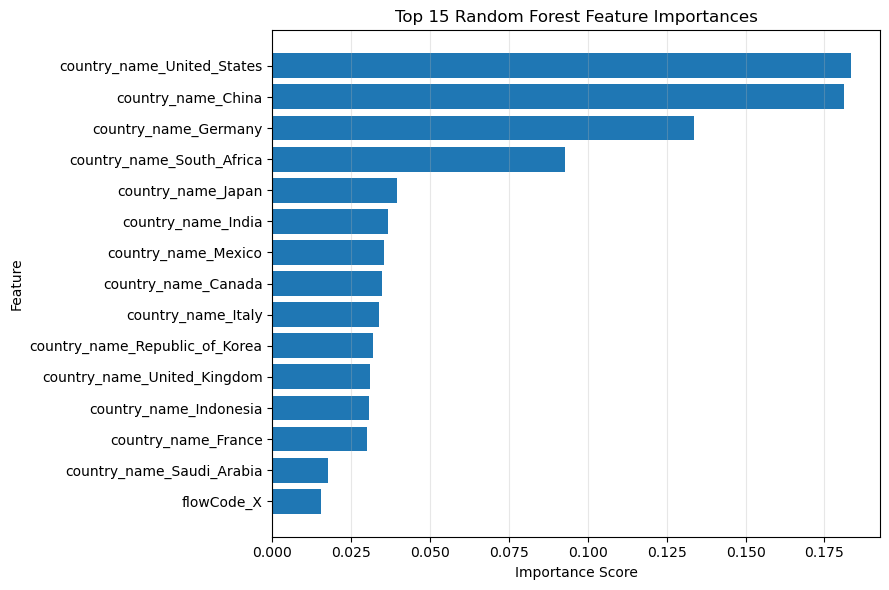

In [99]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

top_features = feature_importance.sort_values(
    "Importance",
    ascending=False
).head(15)

plt.figure(figsize=(9, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Top 15 Random Forest Feature Importances")
plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.gca().invert_yaxis()

plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

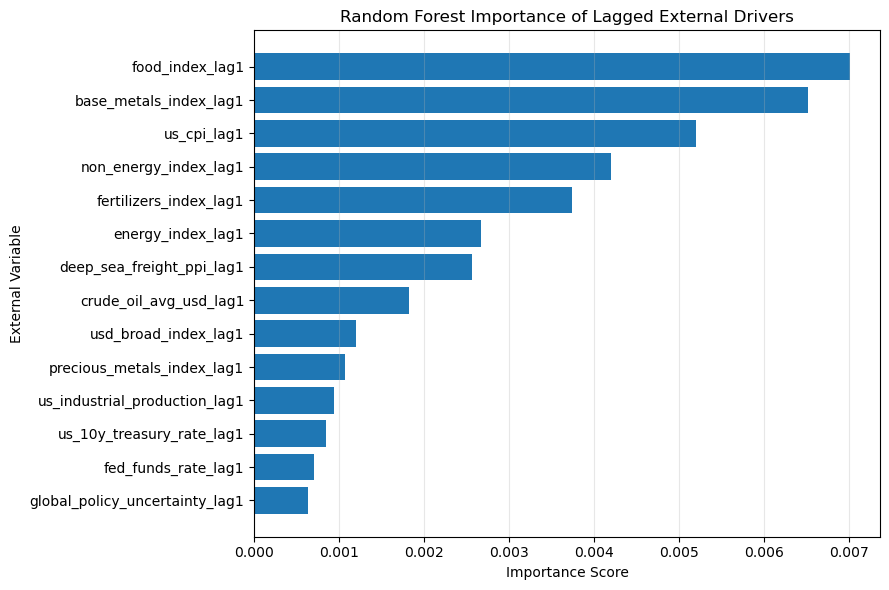

In [100]:
external_importance = feature_importance[
    feature_importance["Feature"].str.endswith("_lag1")
].sort_values("Importance", ascending=False)

plt.figure(figsize=(9, 6))

plt.barh(
    external_importance["Feature"],
    external_importance["Importance"]
)

plt.title("Random Forest Importance of Lagged External Drivers")
plt.xlabel("Importance Score")
plt.ylabel("External Variable")

plt.gca().invert_yaxis()

plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

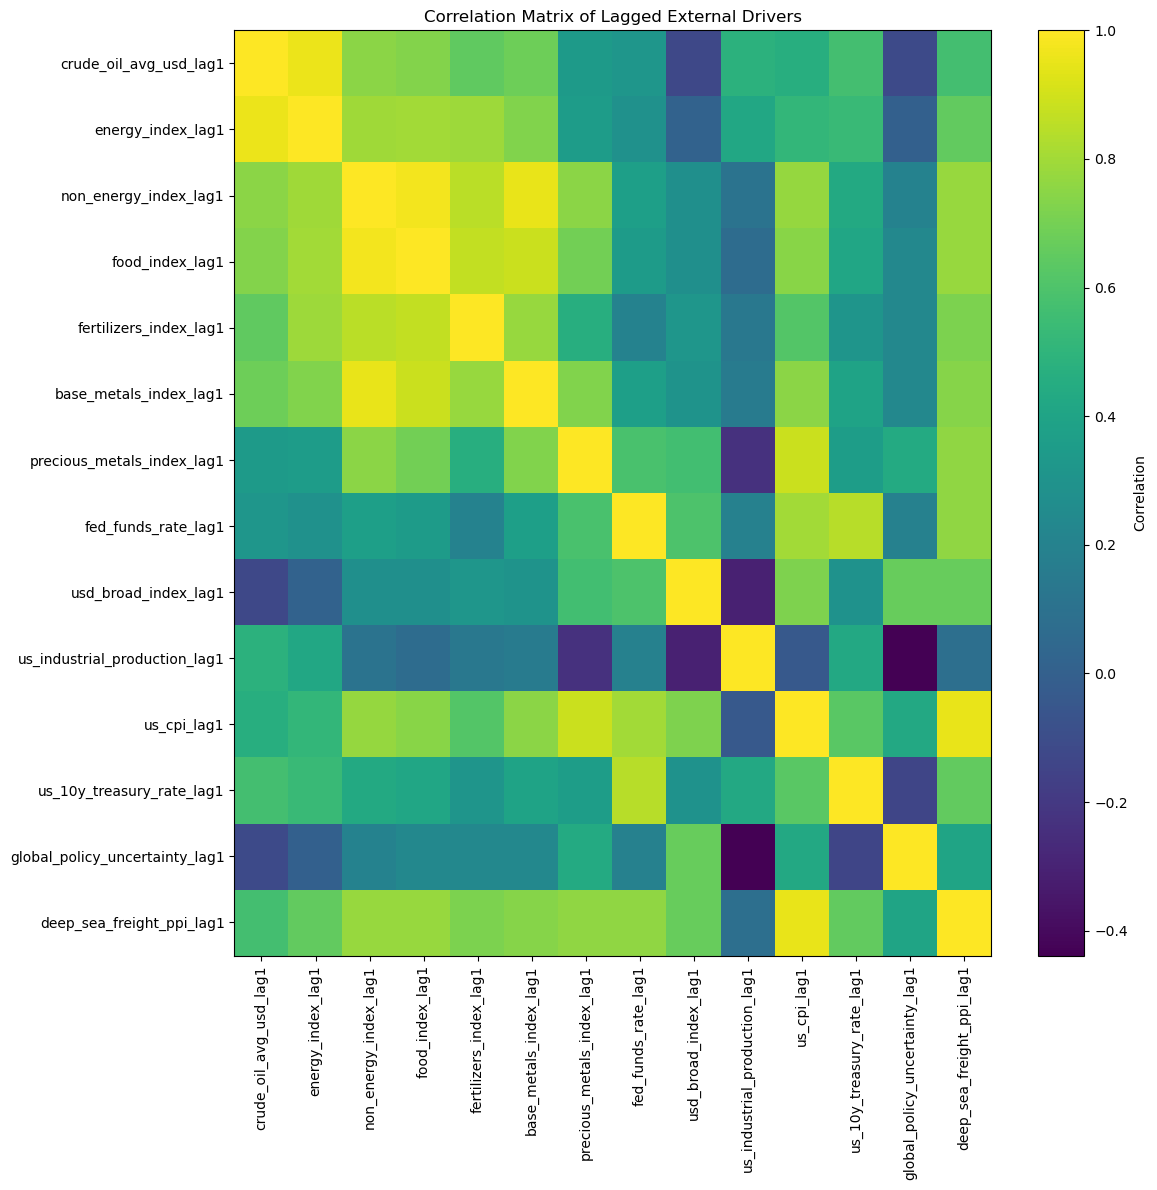

In [103]:
lag_feature_cols = [col + "_lag1" for col in external_cols]

corr_matrix = monthly_external[lag_feature_cols].corr()

plt.figure(figsize=(12, 12))

plt.imshow(corr_matrix, aspect="auto")

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(lag_feature_cols)),
    lag_feature_cols,
    rotation=90
)

plt.yticks(
    range(len(lag_feature_cols)),
    lag_feature_cols
)

plt.title("Correlation Matrix of Lagged External Drivers")

plt.tight_layout()
plt.show()